<a href="https://colab.research.google.com/github/juliosdutra/AulaFCE/blob/main/Reatores_simulation_comentado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Simulação de Reatores CSTR em Série

Este notebook apresenta uma implementação de:

- Modelagem de um CSTR em regime permanente;
- Simulação de reatores em série;
- Cálculo de conversão;
- Visualização gráfica dos resultados.

# Clonar o repositório com as funções do problema

In [1]:
!git clone https://github.com/juliosdutra/AulaFCE.git -qq

## Importando funções do repositório

Após clonar o repositório, utilizamos:

```python
import sys
sys.path.append("/content/AulaFCE")
```

para adicionar a pasta do projeto aos caminhos de busca do Python.

Isso permite importar funções e classes diretamente dos arquivos `.py`
do repositório, transformando-os em módulos reutilizáveis.

---

## Organização do código

Neste exemplo:

- `Reatores_em_serie.py` contém:
  - modelos matemáticos;
  - funções de simulação;
  - parâmetros do problema.

- `graficos_cstr.py` contém:
  - funções de visualização;
  - geração de gráficos.

Essa separação melhora:

- reutilização de código;
- clareza do projeto;
- manutenção;
- escalabilidade.

---

## Importando funções específicas

O comando:

```python
from AulaFCE.Reatores_em_serie import (
    ParametrosCSTR,
    modelo_cstr,
    simula_cstr
)
```

importa apenas os elementos desejados do módulo.

Assim, podemos utilizar diretamente:

```python
CA, X = simula_cstr()
```

sem precisar reescrever as funções no notebook.

---

## Observação importante

Essa abordagem é muito utilizada em:

- projetos científicos;
- bibliotecas Python;
- aplicações de engenharia;
- projetos de machine learning;
- simulações numéricas.

Ela permite organizar melhor os códigos conforme o projeto cresce.

In [2]:
import sys
sys.path.append("/content/AulaFCE")

In [3]:
from AulaFCE.Reatores_em_serie import (
    ParametrosCSTR,
    modelo_cstr,
    simula_cstr
)

# Verificar o *docstring* das funções.

In [4]:
print(ParametrosCSTR.__doc__)


    Classe que armazena os parâmetros de um reator CSTR.

    Condição nominal utilizada:
    ----------------------------
    - Vazão volumétrica: 50.0
    - Volume do reator: 100.0
    - Constante cinética: 0.5

    Essa condição nominal será utilizada como padrão
    caso o usuário não forneça outros valores.

    Atributos
    ---------
    vazao : float
        Vazão volumétrica de alimentação
        [unid. volume/tempo].

    volume : float
        Volume do reator
        [unid. volume].

    constante : float
        Constante cinética de reação de primeira ordem
        [1/tempo].
    


In [5]:
print(modelo_cstr.__doc__)


    Calcula a concentração de saída de um CSTR em regime permanente.

    O modelo considera:
    - mistura perfeita;
    - regime estacionário;
    - reação de primeira ordem.

    Equação:
        CA = (F / (F + V*k)) * CAin

    Parâmetros
    ----------
    CAin : float
        Concentração de entrada do componente A.

    params : ParametrosCSTR
        Objeto contendo os parâmetros do reator.

    Retorna
    -------
    CA : float
        Concentração de saída do componente A.
    


In [6]:
print(simula_cstr.__doc__)


    Simula uma série de reatores CSTR em cascata.

    Cada estágio recebe como entrada a concentração
    de saída do estágio anterior.

    Condição nominal padrão:
    -------------------------
    Caso nenhum parâmetro seja fornecido, cada estágio
    utilizará:

    - F = 50.0
    - V = 100.0
    - k = 0.5

    Parâmetros
    ----------
    CA0 : float, opcional
        Concentração inicial de alimentação
        do primeiro reator.

    num_estagios : int, opcional
        Número de reatores CSTR em série.

    params : list[ParametrosCSTR], opcional
        Lista contendo os parâmetros de cada estágio.

    Retorna
    -------
    CA : ndarray
        Vetor contendo as concentrações de saída
        de cada estágio.

    X : ndarray
        Vetor contendo as conversões acumuladas
        em cada estágio.
    


# Simulação dos reatores CSTR
## Usando os valores nominais

In [7]:
CA, X = simula_cstr(CA0= 1.0, num_estagios=3, params=3*[ParametrosCSTR()])

print('Concentração de saída (mol/L):', CA)
print('Conversão:', X)

Concentração de saída (mol/L): [0.5   0.25  0.125]
Conversão: [0.5   0.75  0.875]


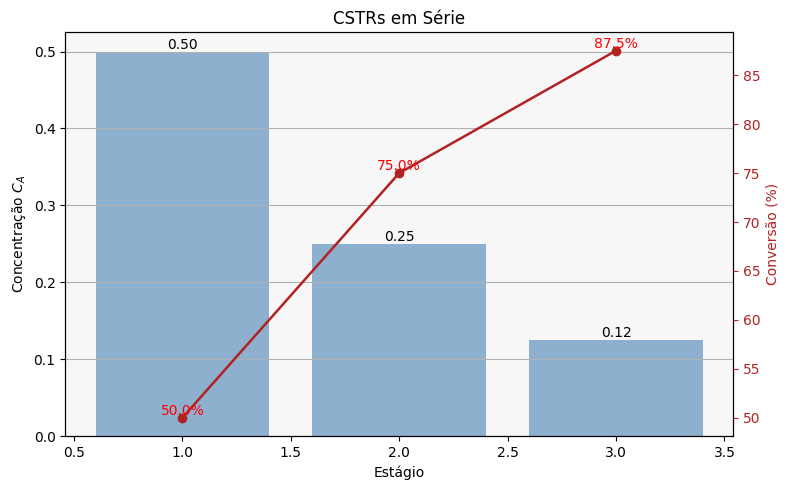

In [8]:
from graficos_cstr import grafico_cstr

grafico_cstr(CA, X)

In [9]:
# ==========================================================
# ANÁLISE 1 — Influência do Número de Reatores
# ==========================================================

"""
Objetivo:
----------
Avaliar como o número de CSTRs em série afeta
a conversão global do sistema.

Pergunta:
----------
À medida que aumentamos o número de estágios,
o sistema se aproxima do comportamento de qual
tipo de reator ideal?
"""

# Lista com diferentes números de estágios
lista_n = [1, 3, 5, 10]

for n in lista_n:

    # Simulação
    CA, X = simula_cstr(
        CA0=1.0,
        num_estagios=n,
        params=n*[ParametrosCSTR()]
    )

    print(f"\nNúmero de reatores = {n}")

    print(f"Conversão final = {100*X[-1]:.2f}%")


Número de reatores = 1
Conversão final = 50.00%

Número de reatores = 3
Conversão final = 87.50%

Número de reatores = 5
Conversão final = 96.88%

Número de reatores = 10
Conversão final = 99.90%


In [10]:
# ==========================================================
# ANÁLISE 2 — Influência da Constante Cinética
# ==========================================================

"""
Objetivo:
----------
Avaliar o efeito da velocidade de reação
sobre a conversão.

Pergunta:
----------
O que acontece com a concentração de saída
quando aumentamos k?
"""

# Diferentes valores de k
lista_k = [0.1, 0.5, 1.0, 2.0]

for k in lista_k:

    print(f"\nConstante cinética k = {k}")

    # Cria parâmetros
    param = ParametrosCSTR(
        vazao=100,
        volume=50,
        constante=k
    )

    # Simulação
    CA, X = simula_cstr(
        CA0=1.0,
        num_estagios=3,
        params=3*[param]
    )

    print(f"Conversão final = {100*X[-1]:.2f}%")


Constante cinética k = 0.1
Conversão final = 13.62%

Constante cinética k = 0.5
Conversão final = 48.80%

Constante cinética k = 1.0
Conversão final = 70.37%

Constante cinética k = 2.0
Conversão final = 87.50%



Sistema com reatores diferentes
Conversão final = 57.26%


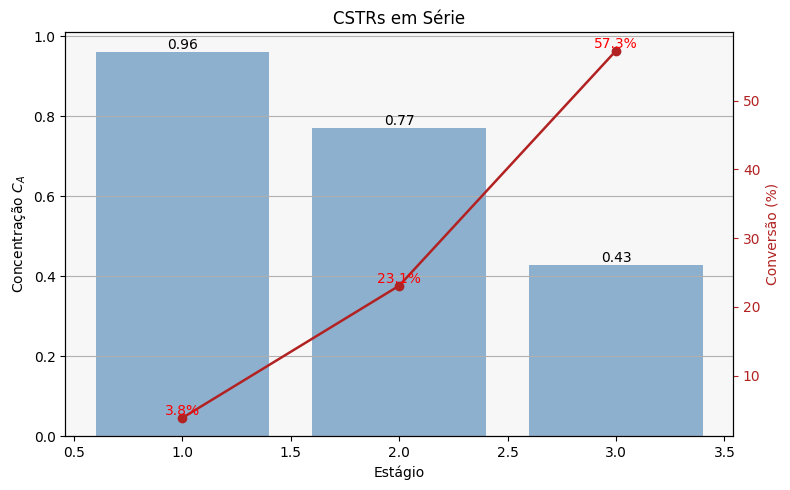

In [11]:
# ==========================================================
# ANÁLISE 3 — Reatores Diferentes em Série
# ==========================================================

"""
Objetivo:
----------
Permitir que cada estágio tenha parâmetros próprios.

Exemplo:
---------
- diferentes volumes;
- diferentes constantes cinéticas;
- diferentes condições operacionais.
"""

# Cada reator possui parâmetros próprios
params = [

    ParametrosCSTR(
        vazao=100,
        volume=20,
        constante=0.2
    ),

    ParametrosCSTR(
        vazao=100,
        volume=50,
        constante=0.5
    ),

    ParametrosCSTR(
        vazao=100,
        volume=80,
        constante=1.0
    )
]

# Simulação
CA, X = simula_cstr(
    CA0=1.0,
    num_estagios=3,
    params=params
)

# Resultados
print("\nSistema com reatores diferentes")

print(f"Conversão final = {100*X[-1]:.2f}%")

grafico_cstr(CA, X)